In [10]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import collections
import glob
import ast
import csv
import ast
import json
import requests
import random
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import rankdata
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from decimal import Decimal

In [11]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def pearson(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = pearsonr(data1, data2)
    formatted_p_value = '{:e}'.format(p_value)
    return correlation, formatted_p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def ylog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('ylog_plot.svg', dpi=300, bbox_inches='tight')
    plt.show()
    
def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
    return result_dict

def getDirectRns(cpd_id):
    direct_rns = set()
    for rn, cpds in rn2cpds.items():
        if cpd_id in cpds:
            direct_rns.add(rn)
    return direct_rns

def rnWith(xgroup, rn2rules, rn2cpds):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        if reaction in rn2cpds:  # only get rns that show up in SI (12872 -> 8558)
            for rule in rules:
                if xgroup in rule:
                    rnWithX.append(reaction)
                    break
    return rnWithX

In [12]:
# fetch assets
x2name = csv2dict('../data/assets/xgroup2/xgroup2name.csv')
x2class = csv2dict('../data/assets/xgroup2/xgroup2class.csv')
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')

rn2cpds = csv2dict('../data/assets/rn2cpds_SI.csv')
rn2eqn = csv2dict('../data/assets/rn2eqn_SI.csv')
rn2rev = csv2dict('../data/assets/rn2reversible.csv')

rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
x2rn = {}
for xgroup in x2ns.keys():
    x2rn[xgroup] = rnWith(xgroup, rn2rules, rn2cpds)

cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')

H2O2_rns = ['R00017_v1', 'R03532_v1', 'R09507_v1', 'R09740_v1', 'R09741_v1', 'R11522', 'R12455', 'R12454']

# Test

In [20]:
result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-23_06-20-16_newModel_NONE_multicore.pkl.gz')

In [17]:
# check new multicore run on Liam PC (with old metabolism model)
result = pd.read_pickle(f'../data/fold_results/liam_check_2024-09-10_14-13-41_no_lookahead_preExpansion_C00002_12461.pkl.gz')

In [14]:
# check new model with jupyter installed on pycharm
result = pd.read_pickle(f'../data/fold_results/2024-09-19_13-56-08_jupyter.pkl.gz')

In [21]:
folditer2rns = {}
for fold, folditer in result.rns_folditer.items():
    if folditer not in folditer2rns.keys():
        folditer2rns[folditer] = [fold]
    else:
        folditer2rns[folditer].append(fold)
print(len(folditer2rns))

cumiter2rns = {}
for cum, cumiter in result.rns_cumiter.items():
    if cumiter not in cumiter2rns.keys():
        cumiter2rns[cumiter] = [cum]
    else:
        cumiter2rns[cumiter].append(cum)
print(len(cumiter2rns))

271
782


In [22]:
enigma_rns_folditer = {}
print('rn_iter  rn   id  cpd  cpd_iter  in H2O2_rns?')
print('---------------------------------------')

for i, rns in folditer2rns.items():
    for rn in rns:
        cpds = rn2cpds[rn]
        for c in cpds:
            if c != 'factor':  # ignore MeCobamineCofactor 
                num = result.cpds_folditer.get(c[-6:], -1)
                if num == -1:
                    print(i, rn, c[-6:], cpd2name[c[-6:]], num, rn in H2O2_rns)
                    enigma_rns_folditer[rn] = (i, num)
                elif num > i:
                    print(i, rn, c[-6:], cpd2name[c[-6:]], num, rn in H2O2_rns)
                    enigma_rns_folditer[rn] = (i, num)
                    
# some Z compounds are acting weird... (Z00035, Z00032, Z00025, Z00018, Z00049)

rn_iter  rn   id  cpd  cpd_iter  in H2O2_rns?
---------------------------------------
6 R11098_v2 Z00035 PLP 11 False
6 R11101_v2 Z00035 PLP 11 False
6 R00996_v2 Z00035 PLP 11 False
10 R00839_v2 Z00032 NAD/NADP 111 False
13 R00801_v1 Z00032 NAD/NADP 111 False
13 R00802_v1 Z00032 NAD/NADP 111 False
13 R00028_v1 Z00032 NAD/NADP 111 False
43 R03083_v2 Z00032 NAD/NADP 111 False
111 R00434_v2 Z00025 Heme 175 False
121 R08210_v3 Z00018 Flavodoxin 281 False
121 R05884_v3 Z00018 Flavodoxin 281 False
121 R05884_v4 Z00018 Flavodoxin 281 False
121 R08210_v4 Z00018 Flavodoxin 281 False
139 R00946_v1 Z00018 Flavodoxin 281 False
175 R03532_v1 C00027 Hydrogen peroxide 305 True
175 R12455 C22173 Harderoheme III -1 True
175 R12455 C00027 Hydrogen peroxide 305 True
175 R11522 C00027 Hydrogen peroxide 305 True
175 R09507_v1 C01371 Alkane -1 True
175 R09507_v1 C00027 Hydrogen peroxide 305 True
232 R00639_v3 Z00049 Ubiquinone 305 False
232 R01045_v3 Z00049 Ubiquinone 305 False
281 R00017_v1 C00027 Hydrogen

165
359
372
372


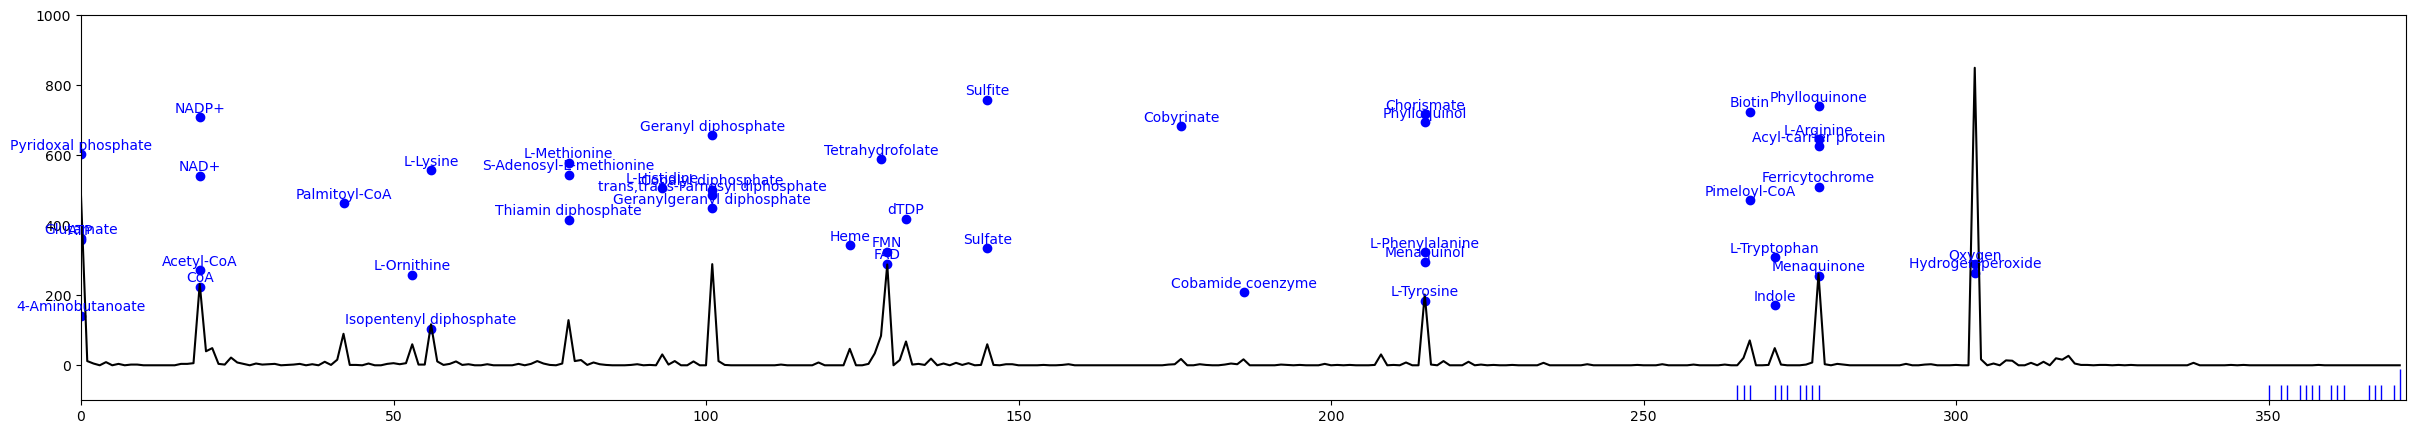

In [9]:
# draw trajectory
folditer2cpd = {}
for c, order in result.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
print(len(folditer2cpdNumFull))

folditer2folds = {}
for fold, folditer in result.folds_folditer.items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)
print(len(folditer2folds))
        
double_injection = []
triple_injection = []
for i, folds in folditer2folds.items():
    if len(folds) == 2:
        double_injection.append(i)
    if len(folds) == 3:
        triple_injection.append(i)
        
# extend end until all injections complete
for i in range(len(folditer2folds) - len(folditer2cpdNumFull)):
    folditer2cpdNumFull[len(folditer2cpdNumFull)] = 0
print(len(folditer2cpdNumFull))

cpd2iter = {}
for cpd in ['C00006', 'C00154', 'C00077', 'C00047', 'C00135', 'C00073', 'C00448', 'C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C00229', 'C05819', 'C03313', 'C00027', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C01063', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00003', 'C00010', 'C00024', 'C00129', 'C00068', 'C00019', 'C00101', 'C00016', 'C00061', 'C00363', 'C00194', 'C00062', 'C00007']:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
                
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations
for key, value in cpd2iter.items():
    position = random.randint(100, 800)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue')
    plt.scatter(value, position-5, color='b')

# Create a rugplot
sns.rugplot(double_injection, height=0.04, color='blue')  # double fold injection
sns.rugplot(triple_injection, height=0.08, color='blue')  # triple fold injection
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
# plt.savefig('folditer_cpds_annotated_2.svg', dpi=300, bbox_inches='tight')
plt.show()

In [58]:
len(enigma_rns_folditer)

24

In [8]:
rn2rules['R11098_v2'], rn2rules['R11101_v2'], rn2rules['R00996_v2']

({frozenset({'spontaneous'}), frozenset({'301'})},
 {frozenset({'spontaneous'})},
 {frozenset({'2003'}), frozenset({'2003', '304'})})

In [9]:
result.folds_folditer['2003']

6

In [10]:
for c in rn2cpds['R00996_v2']:
    print(c, cpd2name[c], result.cpds_folditer[c])

# gated by X2003 and C00109 2-Oxobutanoate, NOT Z00035 PLP

Z00035 PLP 11
C00014 Ammonia 0
C00109 2-Oxobutanoate 6
C00188 L-Threonine 0


In [11]:
rn2rules['R00839_v2'], result.folds_folditer['279']

({frozenset({'2003', '279'}), frozenset({'2002'})}, 19)

In [14]:
# checking NAD/NADP

for c in rn2cpds['R00839_v2']:
    print(c, result.cpds_folditer[c])

Z00030 0
C00092 10
C00001 0
Z00032 111
C00031 10
C04534 10


# The fix (not really... won't fix fold recruitment)

In [24]:
# do cumiter also

enigma_rns_cumiter = {}
print('rn_iter  rn   id  cpd  cpd_iter  in H2O2_rns?')
print('---------------------------------------')

for i, rns in cumiter2rns.items():
    for rn in rns:
        cpds = rn2cpds[rn]
        for c in cpds:
            if c != 'factor':  # ignore MeCobamineCofactor 
                num = result.cpds_cumiter.get(c[-6:], -1)
                if num == -1:
                    print(i, rn, c[-6:], cpd2name[c[-6:]], num, rn in H2O2_rns)
                    enigma_rns_cumiter[rn] = (i, num)
                elif num > i:
                    print(i, rn, c[-6:], cpd2name[c[-6:]], num, rn in H2O2_rns)
                    enigma_rns_cumiter[rn] = (i, num)

rn_iter  rn   id  cpd  cpd_iter  in H2O2_rns?
---------------------------------------
12 R11098_v2 Z00035 PLP 40 False
13 R11101_v2 Z00035 PLP 40 False
11 R00996_v2 Z00035 PLP 40 False
31 R00839_v2 Z00032 NAD/NADP 213 False
52 R00801_v1 Z00032 NAD/NADP 213 False
52 R00802_v1 Z00032 NAD/NADP 213 False
52 R00028_v1 Z00032 NAD/NADP 213 False
121 R03083_v2 Z00032 NAD/NADP 213 False
217 R00434_v2 Z00025 Heme 482 False
271 R08210_v3 Z00018 Flavodoxin 701 False
271 R08210_v4 Z00018 Flavodoxin 701 False
270 R05884_v3 Z00018 Flavodoxin 701 False
270 R05884_v4 Z00018 Flavodoxin 701 False
367 R00946_v1 Z00018 Flavodoxin 701 False
384 R05707_v3 Z00013 FAD 385 False
384 R05705_v3 Z00013 FAD 385 False
384 R09750_v3 Z00013 FAD 385 False
484 R09507_v1 C01371 Alkane -1 True
484 R09507_v1 C00027 Hydrogen peroxide 743 True
483 R03532_v1 C00027 Hydrogen peroxide 743 True
482 R12455 C22173 Harderoheme III -1 True
482 R12455 C00027 Hydrogen peroxide 743 True
482 R11522 C00027 Hydrogen peroxide 743 True
608 

In [59]:
len(enigma_rns_cumiter)  # Z00013 FAD is now included!

27

In [25]:
# rns

rns_folditer_mod = {}
for k,v in result.rns_folditer.items():
    if k in enigma_rns_folditer:
        if enigma_rns_folditer[k][1] == -1:  # remove
            pass
        else:
            rns_folditer_mod[k] = enigma_rns_folditer[k][1]  # mod
    else:
        rns_folditer_mod[k] = v  # same
        
rns_cumiter_mod = {}
for k,v in result.rns_cumiter.items():
    if k in enigma_rns_cumiter:
        if enigma_rns_cumiter[k][1] == -1:  # remove
            pass
        else:
            rns_cumiter_mod[k] = enigma_rns_cumiter[k][1]  # mod
    else:
        rns_cumiter_mod[k] = v  # same

In [26]:
len(rns_folditer_mod), len(result.rns_folditer), len(rns_cumiter_mod), len(result.rns_cumiter)

(7677, 7680, 7677, 7680)

In [27]:
# rules

rules_folditer_mod = {}
for k,v in result.rules_folditer.items():
    if k[0] in enigma_rns_folditer:
        if enigma_rns_folditer[k[0]][1] == -1:  # remove
            pass
        else:
            rules_folditer_mod[k] = enigma_rns_folditer[k[0]][1]  # mod
    else:
        rules_folditer_mod[k] = v  # same
        
rules_cumiter_mod = {}
for k,v in result.rules_cumiter.items():
    if k[0] in enigma_rns_cumiter:
        if enigma_rns_cumiter[k[0]][1] == -1:  # remove
            pass
        else:
            rules_cumiter_mod[k] = enigma_rns_cumiter[k[0]][1]  # mod
    else:
        rules_cumiter_mod[k] = v  # same

In [28]:
len(rules_folditer_mod), len(result.rules_folditer), len(rules_cumiter_mod), len(result.rules_cumiter)

(7560, 7563, 7560, 7563)

# more detective work

In [29]:
rn2rules['R00996_v2']

{frozenset({'2003'}), frozenset({'2003', '304'})}

In [30]:
for rule in rn2rules['R00996_v2']:
    print(rule, result.rules_folditer[('R00996_v2', rule)])

frozenset({'2003'}) 6
frozenset({'304', '2003'}) 12


In [31]:
# reaction is logged when it's first discovered REGARDLESS of which rule
# reactionRule is logged also for re-discovery of same reaction

for rnRules, i in result.rules_folditer.items():
    if rnRules[0] in enigma_rns_folditer:
        print(rnRules, i, enigma_rns_folditer[rnRules[0]])

('R11101_v2', frozenset({'spontaneous'})) 6 (6, 11)
('R00996_v2', frozenset({'2003'})) 6 (6, 11)
('R11098_v2', frozenset({'spontaneous'})) 6 (6, 11)
('R00839_v2', frozenset({'2002'})) 10 (10, 111)
('R00996_v2', frozenset({'304', '2003'})) 12 (6, 11)
('R00802_v1', frozenset({'2002', '12'})) 13 (13, 111)
('R00028_v1', frozenset({'2002', '12'})) 13 (13, 111)
('R00801_v1', frozenset({'2002', '12'})) 13 (13, 111)
('R00801_v1', frozenset({'10'})) 16 (13, 111)
('R00802_v1', frozenset({'10'})) 16 (13, 111)
('R00839_v2', frozenset({'279', '2003'})) 19 (10, 111)
('R11098_v2', frozenset({'301'})) 26 (6, 11)
('R03083_v2', frozenset({'2007', '4002'})) 43 (43, 111)
('R03083_v2', frozenset({'2007', '4002', '2004'})) 46 (43, 111)
('R03083_v2', frozenset({'2002', '328', '2003', '2007', '4002', '2004'})) 94 (43, 111)
('R00802_v1', frozenset({'2002', '355', '12', '4178'})) 97 (13, 111)
('R00028_v1', frozenset({'2002', '355', '12', '4178'})) 97 (13, 111)
('R00801_v1', frozenset({'2002', '355', '12', '4178

In [32]:
for i, rns in folditer2rns.items():
    for rn in rns:
        cpds = rn2cpds[rn]
        for c in cpds:
            if c != 'factor':
                num = result.cpds_folditer.get(c[-6:], -1)
                if num == -1:
                    print(i, rn, c, ':', rn2eqn[rn])
                elif num > i:
                    print(i, rn, c, ':', rn2eqn[rn])

6 R11098_v2 Z00035 : C00109 + C00014 + Z00035 => C20905 + C00001 + Z00035
6 R11101_v2 Z00035 : C20905 + Z00035 => C17234 + Z00035
6 R00996_v2 Z00035 : C00109 + C00014 + Z00035 => C00188 + Z00035
10 R00839_v2 Z00032 : C00031 + C00092 + Z00032 + Z00030 => C04534 + C00001 + Z00032 + Z00030
13 R00801_v1 Z00032 : C00095 + C00031 + Z00032 + Z00034 => C00089 + C00001 + Z00032 + Z00034
13 R00802_v1 Z00032 : C02336 + C00267 + Z00032 + Z00034 => C00089 + C00001 + Z00032 + Z00034
13 R00028_v1 Z00032 : 2C00031 + Z00032 + Z00034 => C00208 + C00001 + Z00032 + Z00034
43 R03083_v2 Z00032 : C04691 + Z00032 + Z00069 => C00944 + C00009 + Z00032 + Z00069
111 R00434_v2 Z00025 : C00942 + C00013 + Z00025 + C00942 + C00013 + Z00039 + Z00055 => C00044 + Z00025 + C00044 + Z00039 + Z00055
121 R08210_v3 Z00018 : 2C00138 + 2C00080 + C11811 + Z00018 + Z00067 => 2C00139 + C00235 + C00001 + Z00018 + Z00067
121 R05884_v3 Z00018 : 2C00139 + C00129 + C00001 + Z00018 + Z00067 => 2C00138 + 2C00080 + C11811 + Z00018 + Z000

In [33]:
for rn in enigma_rns_cumiter:
    print(rn, rn in result.scope.rns)

R11098_v2 True
R11101_v2 True
R00996_v2 True
R00839_v2 True
R00801_v1 True
R00802_v1 True
R00028_v1 True
R03083_v2 True
R00434_v2 True
R08210_v3 True
R08210_v4 True
R05884_v3 True
R05884_v4 True
R00946_v1 True
R05707_v3 True
R05705_v3 True
R09750_v3 True
R09507_v1 True
R03532_v1 True
R12455 True
R11522 True
R00639_v3 True
R01045_v3 True
R00017_v1 True
R09740_v1 True
R09741_v1 True
R12454 True


In [34]:
for rn in H2O2_rns:
    print(rn, rn2eqn[rn])

R00017_v1 2C00125 + 2C00001 + Z00025 => 2C00126 + C00027 + Z00025
R03532_v1 2C00001 + C00028 + Z00025 + 2C00001 + C00028 + Z00025 => C00030 + C00027 + Z00025 + C00030 + C00027 + Z00025
R09507_v1 C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010
R09740_v1 C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025
R09741_v1 C19861 + C00001 + Z00025 => C00162 + C00027 + Z00025
R11522 2C00011 + 4C00001 + C00032 => 2C00027 + C21284
R12455 2C00001 + C00032 + C00011 => C22173 + C00027
R12454 2C00001 + C22173 + C00011 => C21284 + C00027


In [35]:
# check one run: x2recruit = {x: [rns at cumiter of fold injection]}

cumiter2rules = {}
for rule, i in result.rules_cumiter.items():
    if i not in cumiter2rules:
        cumiter2rules[i] = [rule]
    else:
        cumiter2rules[i].append(rule)
        
x2recruit = {}
for x, i in result.folds_cumiter.items():
    if x != 'fold_independent':
        x2recruit[x] = cumiter2rules[i]

In [36]:
for x, rnRules in x2recruit.items():
    for rnRule in rnRules:
        if rnRule[0] in enigma_rns_cumiter.keys():
            print(x, len(rnRules))

2003 5
304 21
12 19
12 19
12 19
10 13
10 13
279 10
301 6
4002 3
2004 3
328 1
355 6
355 6
355 6
4178 6
4178 6
4178 6
108 3
108 3
108 3
868 5
7514 17
7514 17
7514 17
136 3
873 3
258 1
4036 6
4054 6
4035 6


In [37]:
x2recruit['328']

# this fold is recruited for a reaction that cannot happen at that iter

[('R03083_v2', frozenset({'2002', '2003', '2004', '2007', '328', '4002'}))]

In [38]:
enigma_rns_cumiter['R03083_v2']

(121, 213)

In [39]:
rn2eqn['R03083_v2'], result.cpds_cumiter['Z00032']

('C04691 + Z00032 + Z00069 => C00944 + C00009 + Z00032 + Z00069', 213)

# are these Z compounds used in H2O2 reactions?

In [47]:
H2O2_rns

['R00017_v1',
 'R03532_v1',
 'R09507_v1',
 'R09740_v1',
 'R09741_v1',
 'R11522',
 'R12455',
 'R12454']

In [57]:
cpds_in_H2O2_rns = set()

for rn in H2O2_rns:
    print(rn, rn2eqn[rn])
    for c in rn2cpds[rn]:
        cpds_in_H2O2_rns.add(c)

R00017_v1 2C00125 + 2C00001 + Z00025 => 2C00126 + C00027 + Z00025
R03532_v1 2C00001 + C00028 + Z00025 + 2C00001 + C00028 + Z00025 => C00030 + C00027 + Z00025 + C00030 + C00027 + Z00025
R09507_v1 C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010
R09740_v1 C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025
R09741_v1 C19861 + C00001 + Z00025 => C00162 + C00027 + Z00025
R11522 2C00011 + 4C00001 + C00032 => 2C00027 + C21284
R12455 2C00001 + C00032 + C00011 => C22173 + C00027
R12454 2C00001 + C22173 + C00011 => C21284 + C00027


In [52]:
cpds_in_H2O2_rns

{'C00001',
 'C00011',
 'C00027',
 'C00028',
 'C00030',
 'C00032',
 'C00125',
 'C00126',
 'C00162',
 'C01335',
 'C01371',
 'C05102',
 'C19861',
 'C21284',
 'C22173',
 'Z00010',
 'Z00025'}

In [54]:
zs = ['Z00035', 'Z00032', 'Z00025', 'Z00018', 'Z00049']
# H2O2 reactions only contain 2 Z-compounds: 'Z00010', 'Z00025'

## test more runs

In [5]:
def printEnigma(result, cumiter2rns):
    print('rn_iter  rn   id  cpd  cpd_iter  in H2O2_rns?')
    print('---------------------------------------')
    
    for i, rns in cumiter2rns.items():
        for rn in rns:
            cpds = rn2cpds[rn]
            for c in cpds:
                if c != 'factor':  # ignore MeCobamineCofactor 
                    num = result.cpds_cumiter.get(c[-6:], -1)
                    if num == -1:
                        print(i, rn, c[-6:], cpd2name[c[-6:]], num, rn in H2O2_rns)
                    elif num > i:
                        print(i, rn, c[-6:], cpd2name[c[-6:]], num, rn in H2O2_rns)

In [15]:
"""
old model
"""

# old model
# result = pd.read_pickle(f'../data/fold_results/runs_fastest_pre-expansion/2023-09-29_20-41-57_rules_to_rn_randomSeed_55773_preExpansion_NONE.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs_fastest_pre-expansion/2023-09-29_18-15-49_rules_to_rn_randomSeed_1028_preExpansion_C00002_iter20.pkl.gz')

# old model, first run with Harrison fix copy/pasted
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-17_19-39-53_check_pull-request.pkl.gz')

"""
new model
"""

# NONE new Model
result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-22_01-38-26_newModel_NONE.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-22_09-22-44_newModel_NONE.pkl.gz')

# preATP new Model
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-18_03-46-59_newModel_preATP.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-21_04-57-16_newModel_preATP.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-21_06-10-43_newModel_preATP.pkl.gz')

"""
Multicore runs
"""

# multicore Liam PC
# result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-07-08_10-50-55_no_lookahead_preExpansion_C00002_67543.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-07-24_11-10-36_no_lookahead_preExpansion_NONE_83276.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs/2024-06-28_23-31-19_random_fold_ordering_42687.pkl.gz')

# NONE multicore
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-23_13-38-35_newModel_NONE_multicore.pkl.gz')

# test more random runs
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-07-03_23-28-43_random_fold_ordering_39853.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-07-04_01-22-10_random_fold_ordering_82165.pkl.gz')

# test shuffle runs
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-27_22-33-14_shuffle1_90037.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-27_22-33-25_shuffle1_71422.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-30_14-45-50_shuffle2_46922.pkl.gz')
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-06-30_14-45-50_shuffle2_92108.pkl.gz')

# preALL new Model
# result = pd.read_pickle(f'../data/fold_results/runs/test_runs/2024-08-04_00-24-51_no_lookahead_preExpansion_ALL_89633.pkl.gz')
    # all cpds available => enigma is only '-1'

'\nMulticore runs\n'

In [31]:
# result = pd.read_pickle(f'../data/fold_results/reverse_fix_withModel.pkl.gz')
result = pd.read_pickle(f'../data/fold_results/reverse_fix.pkl.gz')

In [32]:
folditer2rns = {}
for fold, folditer in result.rns_folditer.items():
    if folditer not in folditer2rns.keys():
        folditer2rns[folditer] = [fold]
    else:
        folditer2rns[folditer].append(fold)
print(len(folditer2rns))

cumiter2rns = {}
for cum, cumiter in result.rns_cumiter.items():
    if cumiter not in cumiter2rns.keys():
        cumiter2rns[cumiter] = [cum]
    else:
        cumiter2rns[cumiter].append(cum)
print(len(cumiter2rns))

276
778


In [33]:
printEnigma(result, cumiter2rns)

rn_iter  rn   id  cpd  cpd_iter  in H2O2_rns?
---------------------------------------


In [34]:
len(result.scope.cpds)

4294

In [56]:
result.cpds_folditer['C00007'], result.cpds_folditer['C00027'], result.cpds_folditer['Z00025']

(304, 304, 171)

In [59]:
for rn in H2O2_rns:
    print(rn, result.rns_folditer.get(rn, 'na'), rn2eqn[rn], rn2rev[rn])

R00017_v1 na 2C00125 + 2C00001 + Z00025 => 2C00126 + C00027 + Z00025 False
R03532_v1 na 2C00001 + C00028 + Z00025 + 2C00001 + C00028 + Z00025 => C00030 + C00027 + Z00025 + C00030 + C00027 + Z00025 False
R09507_v1 na C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010 True
R09740_v1 304 C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
R09741_v1 304 C19861 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
R11522 304 2C00011 + 4C00001 + C00032 => 2C00027 + C21284 True
R12455 304 2C00001 + C00032 + C00011 => C22173 + C00027 True
R12454 304 2C00001 + C22173 + C00011 => C21284 + C00027 True


In [50]:
for rn in H2O2_rns:
    print('')
    print(rn, rn2eqn[rn], rn2rev[rn])
    for c in rn2cpds[rn]:
        print(c, result.cpds_folditer.get(c, 'na'), cpd2name[c])


R00017_v1 2C00125 + 2C00001 + Z00025 => 2C00126 + C00027 + Z00025 False
C00001 0 H2O
C00126 276 Ferrocytochrome c
C00125 276 Ferricytochrome c
C00027 276 Hydrogen peroxide
Z00025 171 Heme

R03532_v1 2C00001 + C00028 + Z00025 + 2C00001 + C00028 + Z00025 => C00030 + C00027 + Z00025 + C00030 + C00027 + Z00025 False
C00001 0 H2O
C00030 0 Reduced acceptor
C00027 276 Hydrogen peroxide
C00028 0 Acceptor
Z00025 171 Heme

R09507_v1 C01335 + C00001 + Z00025 + Z00010 => C01371 + C00027 + Z00025 + Z00010 True
Z00010 171 Cytochrome
C00001 0 H2O
C01371 na Alkane
C01335 0 ROH
C00027 276 Hydrogen peroxide
Z00025 171 Heme

R09740_v1 C05102 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
C05102 276 alpha-Hydroxy fatty acid
C00162 111 Fatty acid
C00001 0 H2O
C00027 276 Hydrogen peroxide
Z00025 171 Heme

R09741_v1 C19861 + C00001 + Z00025 => C00162 + C00027 + Z00025 True
C00162 111 Fatty acid
C00001 0 H2O
C19861 276 3-Hydroxy fatty acid
C00027 276 Hydrogen peroxide
Z00025 171 Heme

R11522 2C00011 + 4C